# Python 04C: PAP, Wahrheitstabellen und logische Schaltungen

Dieses Notebook behandelt die grafische und boolesche Sicht auf Bedingungen: Programmablaufpläne, Wahrheitstabellen, XOR, NAND, NOR, De-Morgan-Regeln und äquivalente Gatter.

## Inhaltsverzeichnis

- [Programmablaufpläne](#pap)
- [PAP-Symbole](#symbole)
- [Wahrheitstabellen](#wahrheit)
- [Schaltzeichen](#schaltzeichen)
- [XOR](#xor)
- [NAND und NOR](#nand)
- [De-Morgan-Regeln](#demorgan)
- [Boolesche Ausdrücke vereinfachen](#vereinfachen)

<a id="pap"></a>

### Bedingungen als Programmablaufplan (PAP)

Ein **Programmablaufplan**, kurz **PAP**, stellt den Ablauf eines Programms grafisch dar.

Andere gebräuchliche Bezeichnungen sind:

- Flussdiagramm
- Flowchart
- Ablaufdiagramm

Ein PAP zeigt also nicht den fertigen Python-Code, sondern den logischen Ablauf dahinter.

★ **Merksatz**

> Ein PAP zeigt den Weg, den ein Programm durch Entscheidungen und Anweisungen nimmt.

<a id="symbole"></a>

### Die wichtigsten Symbole

| Symbol | Bedeutung |
|---|---|
| Oval | Start oder Ende |
| Raute | Entscheidung oder Bedingung |
| Rechteck | Verarbeitung oder Anweisung |
| Pfeil | Richtung des Programmablaufs |

Bei einer Entscheidung gehen normalerweise zwei Wege von der Raute ab:

- `ja / true`
- `nein / false`

## Programmablaufpläne

Der gezeigte PAP entspricht ungefähr diesem Ablauf:

```text
Start
  ↓
Alter über 18?
  ├── Ja   → tanzen
  └── Nein → Ende
```

Passender Python-Code:

In [ ]:
alter = 20

if alter > 18:
    print("tanzen")

### Wichtiger Unterschied: `> 18` und `>= 18`

Diese beiden Bedingungen bedeuten nicht dasselbe:

```python
alter > 18
```

bedeutet:

> älter als 18

Eine Person mit genau 18 Jahren erfüllt diese Bedingung nicht.

```python
alter >= 18
```

bedeutet:

> 18 Jahre oder älter

Für die Prüfung auf Volljährigkeit ist deshalb normalerweise `>= 18` richtig.

In [ ]:
alter = 18

if alter >= 18:
    print("volljährig")
else:
    print("minderjährig")

### PAP und `if-else`

Ein vollständiger Ablauf mit zwei möglichen Ausgaben sieht so aus:

```text
Start
  ↓
alter >= 18?
  ├── Ja   → status = "volljährig"
  └── Nein → status = "minderjährig"
                  ↓
              Ausgabe
                  ↓
                Ende
```

In [ ]:
alter = 17

if alter >= 18:
    status = "volljährig"
else:
    status = "minderjährig"

print(status)

### Vom PAP zum Python-Code

Beim Übersetzen eines PAPs hilft diese Zuordnung:

| PAP | Python |
|---|---|
| Entscheidung in einer Raute | `if`, `elif`, `else` |
| Bedingung | Vergleich wie `alter >= 18` |
| Ja-Zweig | eingerückter Block unter `if` |
| Nein-Zweig | eingerückter Block unter `else` |
| Verarbeitung | normale Python-Anweisung |

### Übung: PAP gedanklich in Python übersetzen

Ablauf:

```text
Start
  ↓
temperatur < 0?
  ├── Ja   → "Frost"
  └── Nein → "Kein Frost"
                  ↓
                Ende
```

Ergänze den Code:

In [ ]:
temperatur = -2

# Ergänze hier die Bedingung.

### Musterlösung

In [ ]:
temperatur = -2

if temperatur < 0:
    print("Frost")
else:
    print("Kein Frost")

<a id="wahrheit"></a>

### Wahrheitstabellen für `and` und `or`

### `and`

Nur wenn beide Seiten `True` sind, ist das Ergebnis ebenfalls `True`.


In [ ]:
print(True and True)
print(True and False)
print(False and True)
print(False and False)


### `or`

Bei `or` reicht ein einziges `True`.


In [ ]:
print(False or True)
print(False or False)


## Wahrheitstabellen und logische Schaltungen

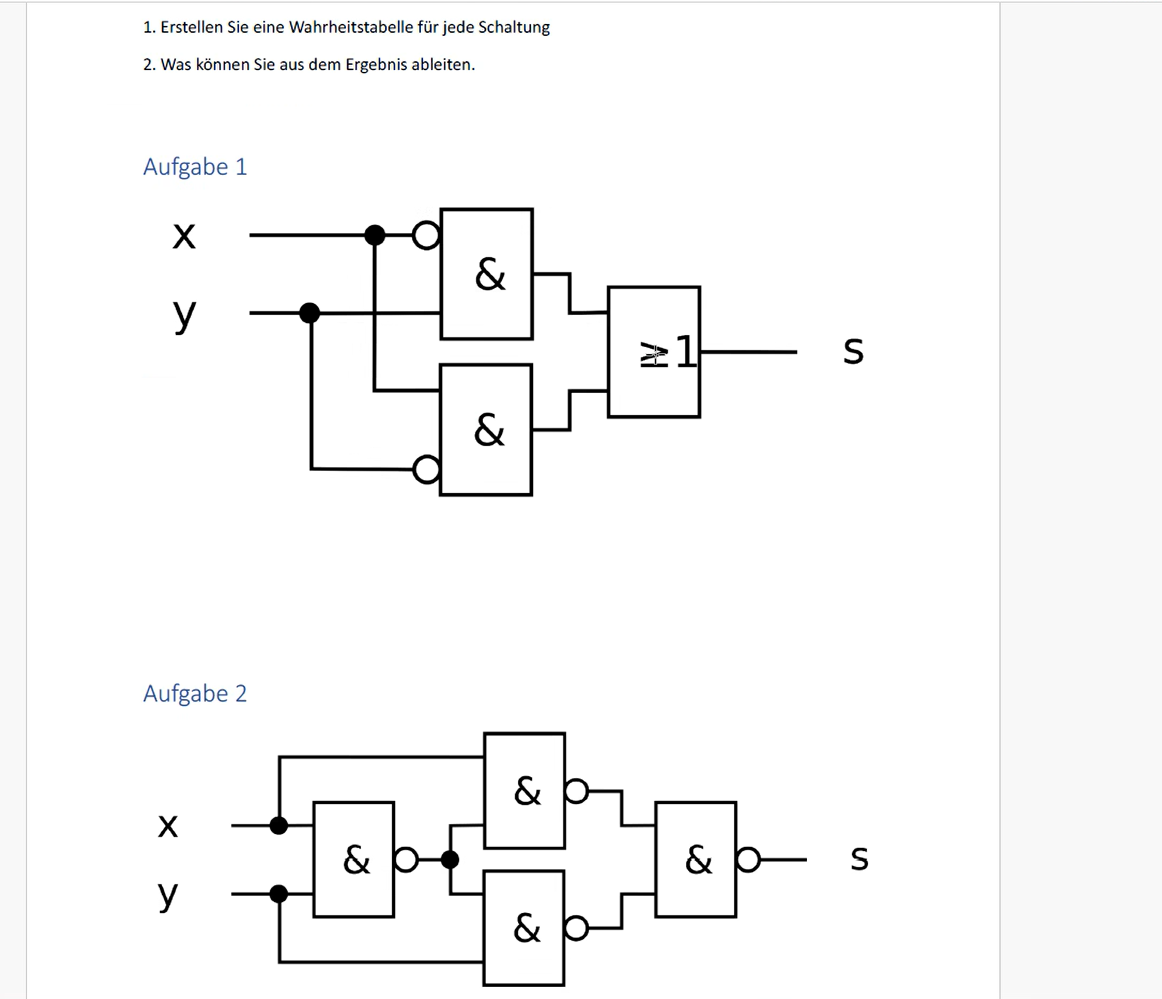


<a id="schaltzeichen"></a>

### Legende der verwendeten Schaltzeichen

| Zeichen oder Darstellung | Bedeutung |
|---|---|
| `x`, `y` | Eingänge der Schaltung |
| `S` | Ausgang der Schaltung |
| Linie | elektrische beziehungsweise logische Verbindung |
| schwarzer Punkt | Leitungen sind an dieser Stelle miteinander verbunden |
| Kreuzung ohne Punkt | Leitungen kreuzen sich nur und sind nicht verbunden |
| `&` im Rechteck | UND-Gatter |
| `≥ 1` im Rechteck | ODER-Gatter: Mindestens ein Eingang muss `1` sein |
| kleiner Kreis an einem Eingang | dieser Eingang wird negiert |
| kleiner Kreis am Ausgang | das Ergebnis des Gatters wird negiert |
| UND-Gatter mit Kreis am Ausgang | NAND-Gatter |
| ODER-Gatter mit Kreis am Ausgang | NOR-Gatter |

★ **Merksatz**

> Ein kleiner Kreis bedeutet immer: Das Signal wird an dieser Stelle umgekehrt.

### Logische Grundzeichen in Formeln

| Zeichen | Bedeutung | Python |
|---|---|---|
| `¬A` | NICHT A | `not A` |
| `A ∧ B` | A UND B | `A and B` |
| `A ∨ B` | A ODER B | `A or B` |
| `A ⊕ B` | A XOR B | `A ^ B` bei booleschen Werten |

In den Tabellen wird meist mit `0` und `1` gearbeitet:

- `0` entspricht `False`
- `1` entspricht `True`

### Wahrheitstabellen und logische Schaltungen

Eine Wahrheitstabelle zeigt für jede mögliche Kombination der Eingänge, welches Ergebnis am Ausgang entsteht.

Bei zwei Eingängen gibt es:

```text
2² = 4 Kombinationen
```

Bei drei Eingängen gibt es:

```text
2³ = 8 Kombinationen
```

Allgemein:

```text
2ⁿ Kombinationen
```

Dabei steht `n` für die Anzahl der Eingänge.

<a id="xor"></a>

### Aufgabe 1: XOR aus UND-, NICHT- und ODER-Verknüpfungen

Die obere UND-Verknüpfung erhält:

```text
¬x UND y
```

Die untere UND-Verknüpfung erhält:

```text
x UND ¬y
```

Danach werden beide Ergebnisse mit ODER verbunden:

```text
S = (¬x ∧ y) ∨ (x ∧ ¬y)
```

### Wahrheitstabelle zu Aufgabe 1

| x | y | ¬x ∧ y | x ∧ ¬y | S |
|---:|---:|---:|---:|---:|
| 0 | 0 | 0 | 0 | 0 |
| 0 | 1 | 1 | 0 | 1 |
| 1 | 0 | 0 | 1 | 1 |
| 1 | 1 | 0 | 0 | 0 |

Das Ergebnis ist `1`, wenn die Eingänge unterschiedlich sind.

Das ist eine XOR-Verknüpfung:

```text
S = x XOR y
```

In [ ]:
x = True
y = False

s = (not x and y) or (x and not y)

print("S =", int(s))

Bei booleschen Werten kann XOR in Python auch mit `^` geschrieben werden:

In [ ]:
x = True
y = False

s = x ^ y

print("S =", int(s))

Wichtig:

Python besitzt kein Schlüsselwort `xor`.

Der Operator `^` ist eigentlich ein bitweiser XOR-Operator. Bei `True` und `False` funktioniert er aber wie ein logisches XOR.

<a id="nand"></a>

### Aufgabe 2: XOR nur mit NAND-Gattern

Ein UND-Gatter mit einem kleinen Kreis am Ausgang ist ein NAND-Gatter.

NAND bedeutet:

```text
NOT AND
```

Also:

```text
NAND(A, B) = ¬(A ∧ B)
```

### Zwischenergebnisse der Schaltung

```text
A = ¬(x ∧ y)
B = ¬(x ∧ A)
C = ¬(A ∧ y)
S = ¬(B ∧ C)
```

### Wahrheitstabelle zu Aufgabe 2

| x | y | A = ¬(x∧y) | B = ¬(x∧A) | C = ¬(A∧y) | S = ¬(B∧C) |
|---:|---:|---:|---:|---:|---:|
| 0 | 0 | 1 | 1 | 1 | 0 |
| 0 | 1 | 1 | 1 | 0 | 1 |
| 1 | 0 | 1 | 0 | 1 | 1 |
| 1 | 1 | 0 | 1 | 1 | 0 |

Auch hier gilt:

```text
S = x XOR y
```

In [ ]:
x = True
y = False

a = not (x and y)
b = not (x and a)
c = not (a and y)
s = not (b and c)

print("A =", int(a))
print("B =", int(b))
print("C =", int(c))
print("S =", int(s))

### Was kann man aus beiden Aufgaben ableiten?

Beide Schaltungen liefern dieselbe Wahrheitstabelle:

| x | y | S |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

XOR bedeutet:

> Der Ausgang ist genau dann `1`, wenn die Eingänge unterschiedlich sind.

### Wichtige Erkenntnis zu NAND

Aufgabe 2 zeigt, dass XOR nur mit NAND-Gattern aufgebaut werden kann.

NAND gilt als **universelles Gatter**. Das bedeutet:

> Mit genügend NAND-Gattern lassen sich auch andere logische Verknüpfungen aufbauen.

Für das Verständnis reicht zunächst:

- NAND ist ein negiertes UND
- mehrere NAND-Gatter können zusammen komplexere Schaltungen bilden
- unterschiedliche Schaltungen können dieselbe Wahrheitstabelle besitzen

<a id="demorgan"></a>

### Äquivalente Gatter und De-Morgan-Regeln

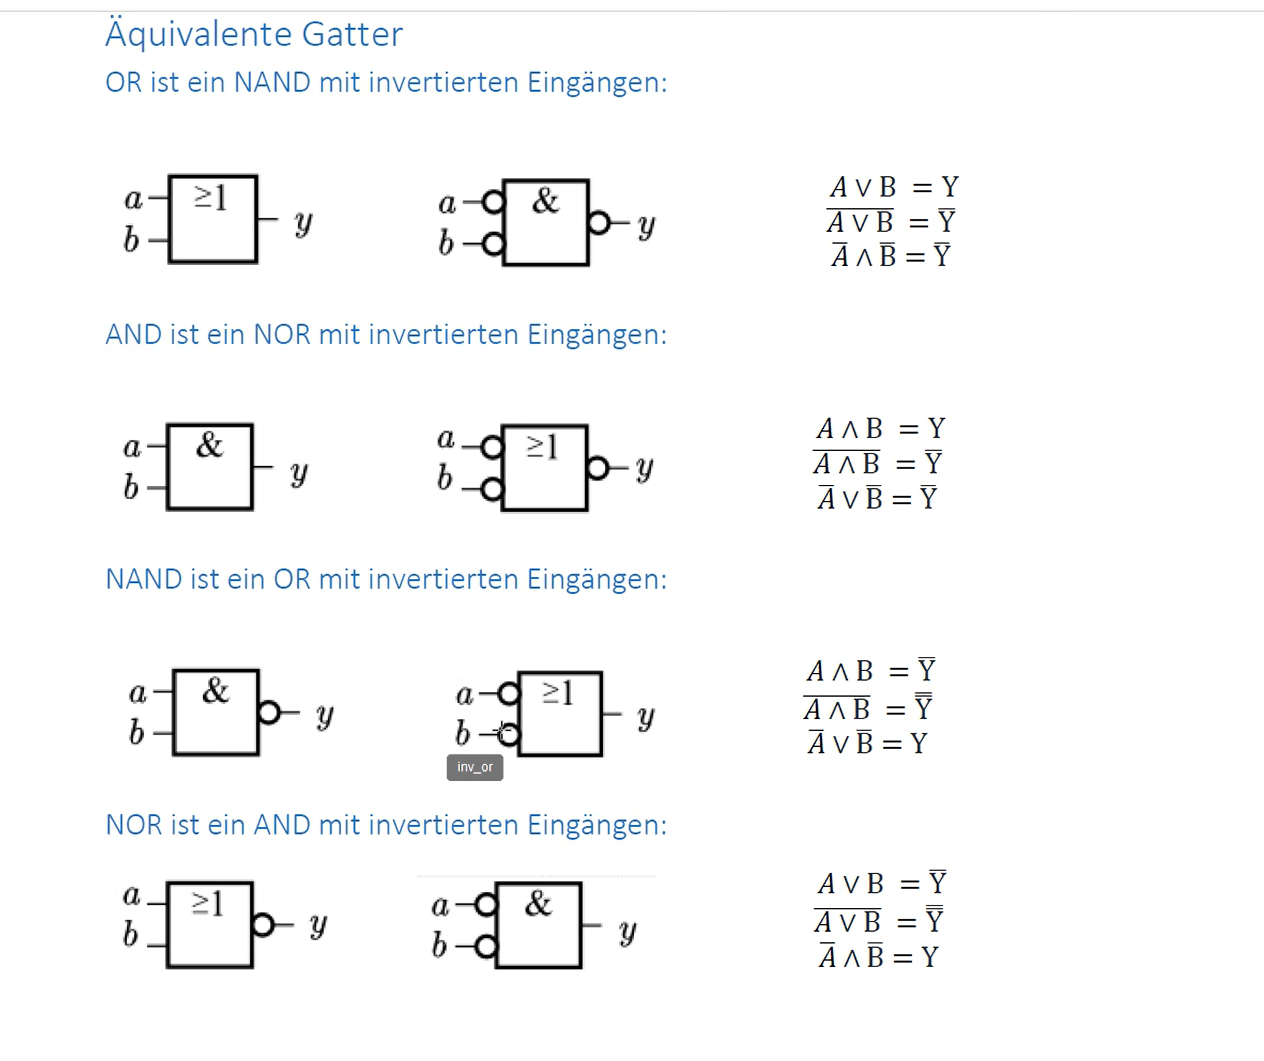


### Warum spricht man von äquivalenten Gattern?

Zwei Schaltungen sind **äquivalent**, wenn sie für alle möglichen Eingangswerte immer dasselbe Ergebnis liefern.

Die Bauteile können dabei unterschiedlich aussehen. Entscheidend ist die Wahrheitstabelle.

★ **Merksatz**

> Gleiche Wahrheitstabelle bedeutet gleiche logische Funktion.

### Die beiden De-Morgan-Regeln

Die De-Morgan-Regeln zeigen, wie eine Negation über eine Klammer verteilt wird.

Erste Regel:

```text
¬(A ∧ B) = ¬A ∨ ¬B
```

In Worten:

> NICHT von „A UND B“ ist dasselbe wie „NICHT A ODER NICHT B“.

Zweite Regel:

```text
¬(A ∨ B) = ¬A ∧ ¬B
```

In Worten:

> NICHT von „A ODER B“ ist dasselbe wie „NICHT A UND NICHT B“.

### Der wichtigste Merksatz

Wenn eine Negation über eine Klammer gezogen wird:

- UND wird zu ODER
- ODER wird zu UND
- alle beteiligten Eingänge werden negiert

Also:

```text
¬(A UND B)  →  ¬A ODER ¬B
¬(A ODER B) →  ¬A UND ¬B
```

### ODER als NAND mit invertierten Eingängen

Normales ODER:

```text
Y = A ∨ B
```

Gleichwertige Form:

```text
Y = ¬(¬A ∧ ¬B)
```

Ablauf:

1. `A` negieren
2. `B` negieren
3. beide Werte mit UND verbinden
4. das Ergebnis erneut negieren

Dadurch entsteht wieder ein ODER.

In [ ]:
A = True
B = False

oder_normal = A or B
oder_als_nand = not ((not A) and (not B))

print("Normales ODER:", oder_normal)
print("ODER als NAND:", oder_als_nand)

### UND als NOR mit invertierten Eingängen

Normales UND:

```text
Y = A ∧ B
```

Gleichwertige Form:

```text
Y = ¬(¬A ∨ ¬B)
```

Ablauf:

1. `A` negieren
2. `B` negieren
3. beide Werte mit ODER verbinden
4. das Ergebnis erneut negieren

Dadurch entsteht wieder ein UND.

In [ ]:
A = True
B = False

und_normal = A and B
und_als_nor = not ((not A) or (not B))

print("Normales UND:", und_normal)
print("UND als NOR:", und_als_nor)

### NAND als ODER mit invertierten Eingängen

NAND bedeutet:

```text
¬(A ∧ B)
```

Nach De Morgan gilt:

```text
¬(A ∧ B) = ¬A ∨ ¬B
```

Also ist ein NAND gleichwertig zu einem ODER mit invertierten Eingängen.

In [ ]:
A = True
B = False

nand_normal = not (A and B)
nand_als_oder = (not A) or (not B)

print("NAND:", nand_normal)
print("ODER mit invertierten Eingängen:", nand_als_oder)

### NOR als UND mit invertierten Eingängen

NOR bedeutet:

```text
¬(A ∨ B)
```

Nach De Morgan gilt:

```text
¬(A ∨ B) = ¬A ∧ ¬B
```

Also ist ein NOR gleichwertig zu einem UND mit invertierten Eingängen.

In [ ]:
A = True
B = False

nor_normal = not (A or B)
nor_als_und = (not A) and (not B)

print("NOR:", nor_normal)
print("UND mit invertierten Eingängen:", nor_als_und)

### Übersicht der äquivalenten Gatter

| Ursprüngliche Funktion | Äquivalente Form |
|---|---|
| `A ∨ B` | `¬(¬A ∧ ¬B)` |
| `A ∧ B` | `¬(¬A ∨ ¬B)` |
| `¬(A ∧ B)` | `¬A ∨ ¬B` |
| `¬(A ∨ B)` | `¬A ∧ ¬B` |

### Wahrheitstabelle zur Kontrolle

Die De-Morgan-Regeln lassen sich mit einer Wahrheitstabelle überprüfen:

| A | B | ¬(A∧B) | ¬A∨¬B | ¬(A∨B) | ¬A∧¬B |
|---:|---:|---:|---:|---:|---:|
| 0 | 0 | 1 | 1 | 1 | 1 |
| 0 | 1 | 1 | 1 | 0 | 0 |
| 1 | 0 | 1 | 1 | 0 | 0 |
| 1 | 1 | 0 | 0 | 0 | 0 |

Die jeweils zusammengehörenden Spalten sind identisch.

### Python-Gegenprüfung für alle Kombinationen

In [ ]:
for A in (False, True):
    for B in (False, True):
        links_1 = not (A and B)
        rechts_1 = (not A) or (not B)

        links_2 = not (A or B)
        rechts_2 = (not A) and (not B)

        print(
            "A =", int(A),
            "B =", int(B),
            "| Regel 1:", int(links_1), int(rechts_1),
            "| Regel 2:", int(links_2), int(rechts_2)
        )

### Warum ist das für Programmierung wichtig?

De Morgan hilft dabei:

- komplizierte Bedingungen umzuschreiben
- Negationen verständlicher zu machen
- große `if`-Bedingungen zu vereinfachen
- Schaltungen mit anderen Gattern nachzubauen
- NAND und NOR als universelle Gatter zu verstehen

### Beispiel aus Python

Diese Bedingung:

```python
not (eingeloggt and ist_admin)
```

ist nach De Morgan gleichwertig zu:

```python
(not eingeloggt) or (not ist_admin)
```

Beide Ausdrücke liefern immer dasselbe Ergebnis.

In [ ]:
eingeloggt = True
ist_admin = False

variante_1 = not (eingeloggt and ist_admin)
variante_2 = (not eingeloggt) or (not ist_admin)

print(variante_1)
print(variante_2)

### Übung: De-Morgan-Regel anwenden

Forme diesen Ausdruck um:

```python
not (A or B)
```

Verwende nur `not` und `and`.

In [ ]:
A = True
B = False

# Ergänze hier die äquivalente Bedingung.

#### Musterlösung

In [ ]:
A = True
B = False

ergebnis = (not A) and (not B)

print(ergebnis)

<a id="vereinfachen"></a>

### Große boolesche Ausdrücke vereinfachen

Ein Ausdruck wie:

```python
(not A and B and not C) or     (A and B and not C) or     (A and not B and C) or     (A and B and C)
```

ist schwer zu lesen.

Die ersten beiden Teile vereinfachen sich zu:

```python
B and not C
```

Die letzten beiden Teile vereinfachen sich zu:

```python
A and C
```

Damit entsteht:

In [ ]:
A = True
B = True
C = True

X = (B and not C) or (A and C)

print("X =", int(X))

★ **Praxis-Merksatz**

> Große Bedingungen zuerst in benannte Teilbedingungen zerlegen oder logisch vereinfachen.

### Übung: XOR-Wahrheitstabelle mit Python erzeugen

Die Schleifen erzeugen alle vier Kombinationen der Eingänge.

In [ ]:
for x in (False, True):
    for y in (False, True):
        s = x ^ y

        print(
            "x =", int(x),
            "y =", int(y),
            "S =", int(s)
        )

Ausgabe:

```text
x = 0 y = 0 S = 0
x = 0 y = 1 S = 1
x = 1 y = 0 S = 1
x = 1 y = 1 S = 0
```

## Kurz-Check

- Kann ich die zentralen Begriffe in eigenen Worten erklären?
- Kann ich den Beispielcode ohne Vorlage nachvollziehen?
- Weiß ich, wann diese Technik sinnvoll ist?